In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import string

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "DejaVu Serif",
    }
)

CHECKPOINT = Path("checkpoint/checkpoint_mermaid.jsonl")
REPORT = Path("data/sonar_report_mermaid_stratified.json")

# ── Load checkpoint ───────────────────────────────────────────
records = []
with CHECKPOINT.open(encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        if rec.get("type") == "issue":
            records.append(rec)

df = pd.DataFrame(records)
df = df.drop_duplicates(subset="id", keep="last").reset_index(drop=True)

# Expand agent_durations dict into columns
durations = df["agent_durations"].apply(pd.Series).add_prefix("dur_")
df = pd.concat([df.drop(columns="agent_durations"), durations], axis=1)

# ── Join with report for issue type ──────────────────────────
report = json.load(REPORT.open())
type_map = {issue["id"]: issue.get("type", "UNKNOWN") for issue in report["issues"]}
df["issue_type"] = df["id"].map(type_map).fillna("UNKNOWN")


# ── Outcome categorization ────────────────────────────────────
# False Positive: resolved=False and fewer than MAX_RETRIES (3) rejection reasons
# Failed: resolved=False and 3 rejection reasons — exhausted all retries
# Resolved: resolved=True
def categorize(row):
    if row["resolved"]:
        return "Resolved"
    if len(row["rejection_reasons"]) < 3:
        return "False Positive"
    return "Failed"


df["outcome"] = df.apply(categorize, axis=1)
df["attempts"] = df["rejection_reasons"].apply(len) + df["resolved"].astype(int)
df["file_short"] = df["file"].apply(lambda p: Path(p).name)

# Expand rejection_reasons list into columns
rejection_expanded = df["rejection_reasons"].apply(pd.Series).add_prefix("rejection_reason_").fillna("")
df = pd.concat([df.drop(columns="rejection_reasons"), rejection_expanded], axis=1)

print(f"Total issues : {len(df)}")
print(df["outcome"].value_counts().to_string())

Total issues : 100
outcome
Resolved          61
Failed            34
False Positive     5


/tmp/ipykernel_8029/3986263457.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  pie_chart_axis.get_figure().show()


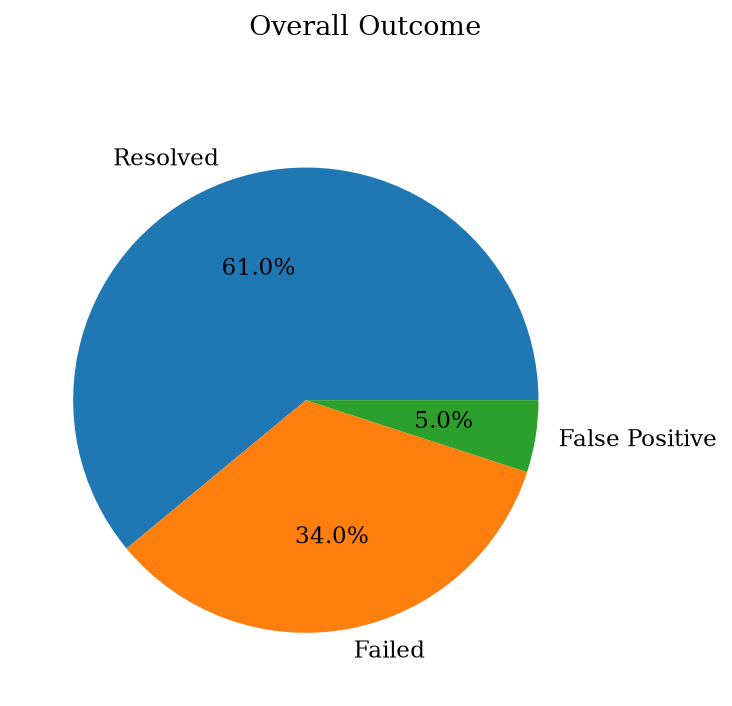

In [11]:
# Overall
OUTCOME_ORDER = ["Resolved", "Failed", "False Positive"]

OUTCOME_COLORS = {
    "Resolved": "#4caf50",
    "Failed": "#f44336",
    "False Positive": "#ff9800",
}

counts = (
    df["outcome"]
    .value_counts()
    .reindex(OUTCOME_ORDER, fill_value=0)
)

pie_chart_axis = counts.plot.pie("outcome", figsize=(5, 5), autopct="%1.1f%%", color=[OUTCOME_COLORS[o] for o in OUTCOME_ORDER])

pie_chart_axis.get_figure().suptitle("Overall Outcome")
pie_chart_axis.get_figure().tight_layout()
pie_chart_axis.get_figure().savefig("results/overall_outcome.png", bbox_inches="tight")
pie_chart_axis.get_figure().show()

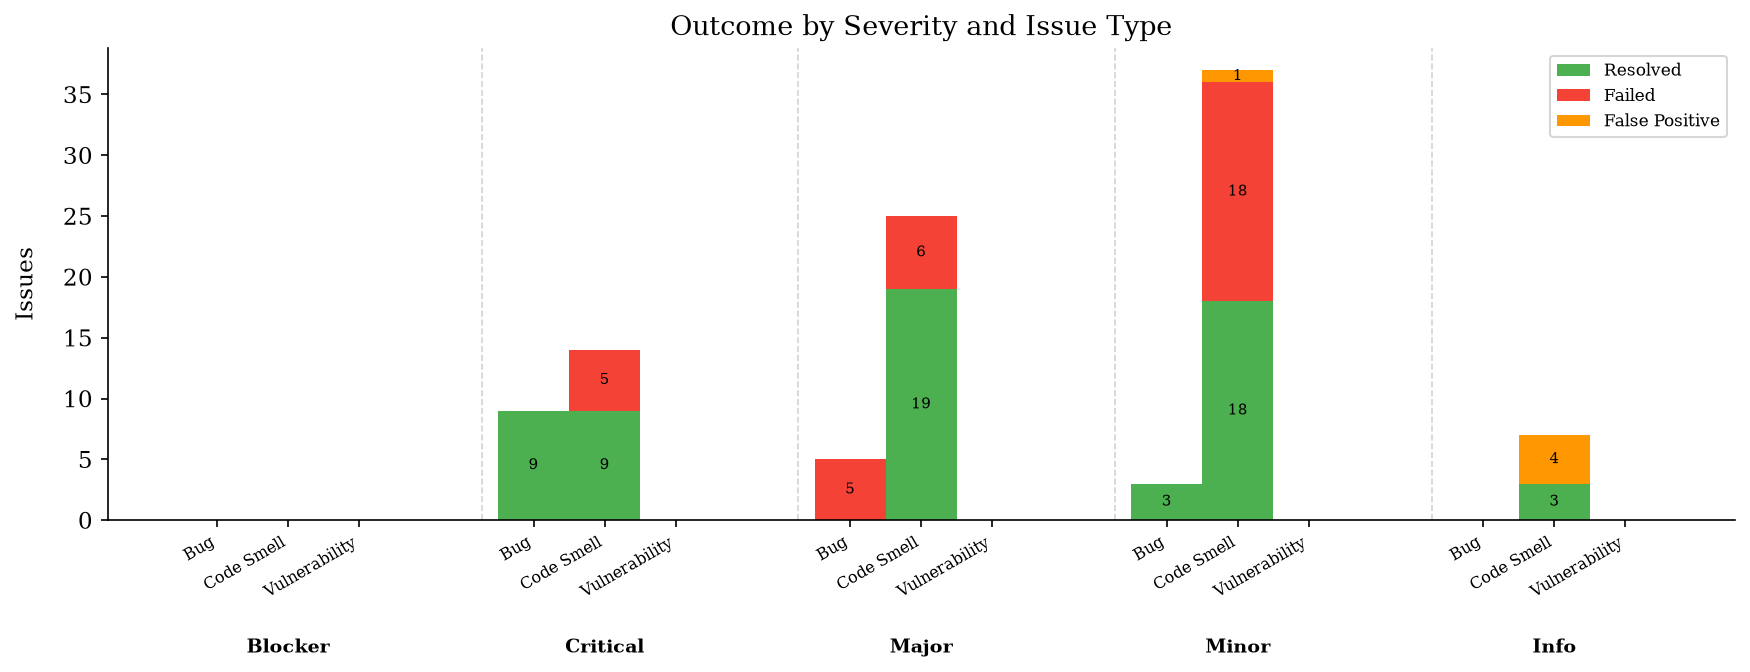

In [12]:
SEVERITY_ORDER = ["BLOCKER", "CRITICAL", "MAJOR", "MINOR", "INFO"]
TYPE_ORDER = ["BUG", "CODE_SMELL", "VULNERABILITY"]
OUTCOME_ORDER = ["Resolved", "Failed", "False Positive"]

# Multi-index pivot: (severity, issue_type) × outcome
mi = pd.MultiIndex.from_product(
    [SEVERITY_ORDER, TYPE_ORDER], names=["severity", "issue_type"]
)
pivot = (
    df.groupby(["severity", "issue_type", "outcome"])
    .size()
    .unstack(fill_value=0)
    .reindex(mi, fill_value=0)
    .reindex(columns=OUTCOME_ORDER, fill_value=0)
)

n_sev, n_type = len(SEVERITY_ORDER), len(TYPE_ORDER)
bar_w, group_gap = 0.55, 0.8

x_pos = [
    i * (n_type * bar_w + group_gap) + j * bar_w
    for i in range(n_sev)
    for j in range(n_type)
]

fig, ax = plt.subplots(figsize=(14, 5))
bottoms = np.zeros(n_sev * n_type)

for outcome in OUTCOME_ORDER:
    vals = pivot[outcome].values
    bars = ax.bar(
        x_pos, vals, width=bar_w, bottom=bottoms,
        color=OUTCOME_COLORS[outcome], label=outcome,
    )
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                str(int(v)), ha="center", va="center", fontsize=7,
            )
    bottoms += vals

# Level 1 — issue type labels
ax.set_xticks(x_pos)
ax.set_xticklabels(
    [string.capwords(TYPE_ORDER[j].replace("_", " ")) for _ in range(n_sev) for j in range(n_type)],
    fontsize=7.5, rotation=30, ha="right",
)

# Level 2 — severity group labels (below type labels)
for i, sev in enumerate(SEVERITY_ORDER):
    center = i * (n_type * bar_w + group_gap) + (n_type - 1) * bar_w / 2
    ax.text(
        center, -0.25, string.capwords(sev),
        ha="center", va="top", fontsize=9, fontweight="bold",
        transform=ax.get_xaxis_transform(),
    )

# Vertical separators between severity groups
for i in range(1, n_sev):
    sep = i * (n_type * bar_w + group_gap) - group_gap / 2
    ax.axvline(sep, color="lightgray", linewidth=0.8, linestyle="--")

ax.set_ylabel("Issues", labelpad=12)
ax.set_title("Outcome by Severity and Issue Type")
ax.legend(loc="upper right", fontsize=8)
fig.subplots_adjust(bottom=0.25)
fig.savefig("results/outcome_by_severity_type.png", bbox_inches="tight")
plt.show()

In [13]:
# ── Tables ────────────────────────────────────────────────────
total = len(df)
print(
    f"Overall resolution rate : {df['resolved'].sum()}/{total} = {df['resolved'].mean()*100:.1f}%"
)
print(
    f"False positive rate     : {(df['outcome']=='False Positive').sum()}/{total} = {(df['outcome']=='False Positive').mean()*100:.1f}%"
)


def outcome_table(group_col, order):
    tbl = (
        pd.DataFrame(
            {
                "Total": df.groupby(group_col).size(),
                "Resolved": df[df["outcome"] == "Resolved"].groupby(group_col).size(),
                "Failed": df[df["outcome"] == "Failed"].groupby(group_col).size(),
                "False Positive": df[df["outcome"] == "False Positive"]
                .groupby(group_col)
                .size(),
            }
        )
        .fillna(0)
        .astype(int)
        .reindex(order, fill_value=0)
    )
    tbl["Rate (%)"] = (tbl["Resolved"] / tbl["Total"].replace(0, np.nan) * 100).round(1)
    return tbl


print("\nBy Severity:")
print(outcome_table("severity", SEVERITY_ORDER).to_string())

print("\nBy Type:")
print(outcome_table("issue_type", TYPE_ORDER).to_string())

Overall resolution rate : 61/100 = 61.0%
False positive rate     : 5/100 = 5.0%

By Severity:
          Total  Resolved  Failed  False Positive  Rate (%)
severity                                                   
BLOCKER       0         0       0               0       NaN
CRITICAL     23        18       5               0      78.3
MAJOR        30        19      11               0      63.3
MINOR        40        21      18               1      52.5
INFO          7         3       0               4      42.9

By Type:
               Total  Resolved  Failed  False Positive  Rate (%)
issue_type                                                      
BUG               17        12       5               0      70.6
CODE_SMELL        83        49      29               5      59.0
VULNERABILITY      0         0       0               0       NaN


In [ ]:
# ── Pre / Post SonarQube Analysis ────────────────────────────
from collections import Counter

before_raw = json.load(Path("data/sonar_report_mermaid.json").open())
after_raw  = json.load(Path("data/sonar_report_mermaid_after.json").open())
strat_raw  = json.load(Path("data/sonar_report_mermaid_stratified.json").open())

strat_map       = {i["id"]: i for i in strat_raw["issues"]}
after_ids_full  = {i["id"] for i in after_raw["issues"]}
bm, am          = before_raw["measures"], after_raw["measures"]

before_by_comp: dict = {}
after_by_comp: dict  = {}
for i in before_raw["issues"]:
    before_by_comp.setdefault(i["component"], set()).add(i["id"])
for i in after_raw["issues"]:
    after_by_comp.setdefault(i["component"], set()).add(i["id"])

# ── 1. Issue Resolution Rate ──────────────────────────────────
sample_ids     = set(strat_map.keys())
sonar_resolved = sample_ids - after_ids_full

print("=" * 62)
print("1. ISSUE RESOLUTION RATE")
print("=" * 62)
print(f"  System-marked resolved   : {df['resolved'].sum()} / {len(df)} = {df['resolved'].mean()*100:.1f}%")
print(f"  SonarQube-confirmed      : {len(sonar_resolved)} / {len(sample_ids)} = {len(sonar_resolved)/len(sample_ids)*100:.1f}%")
print(f"  Discrepancy              : {df['resolved'].sum() - len(sonar_resolved)} issue(s) marked resolved but still open in post-scan")
print("\n  By Severity:")
print(outcome_table("severity", SEVERITY_ORDER)[["Total", "Resolved", "Rate (%)"]].to_string())
print("\n  By Issue Type:")
print(outcome_table("issue_type", TYPE_ORDER)[["Total", "Resolved", "Rate (%)"]].to_string())

# ── 2. False Positive Rate ────────────────────────────────────
fp_df = df[df["outcome"] == "False Positive"]
print()
print("=" * 62)
print("2. FALSE POSITIVE RATE")
print("=" * 62)
print(f"  False positives : {len(fp_df)} / {len(df)} = {len(fp_df)/len(df)*100:.1f}%")
print("\n  By Rule:")
print(fp_df["rule"].value_counts().rename("count").to_string())
print("\n  By Severity:")
print(fp_df["severity"].value_counts().rename("count").to_string())

# ── 3. Regression Rate ────────────────────────────────────────
resolved_components = {
    strat_map[row.id]["component"]
    for row in df[df["resolved"]].itertuples()
    if row.id in strat_map
}
regression_files: dict = {}
for comp in resolved_components:
    new_ids = after_by_comp.get(comp, set()) - before_by_comp.get(comp, set())
    if new_ids:
        new_issues = [i for i in after_raw["issues"] if i["id"] in new_ids]
        regression_files[comp.split(":")[-1]] = new_issues

n_touched   = len(resolved_components)
n_regressed = len(regression_files)
total_new   = sum(len(v) for v in regression_files.values())

print()
print("=" * 62)
print("3. REGRESSION RATE")
print("=" * 62)
print(f"  Files with resolved issues       : {n_touched}")
print(f"  Files with net-new issues        : {n_regressed}  ({n_regressed/n_touched*100:.1f}%)")
print(f"  Total net-new issues introduced  : {total_new}")
print("\n  Affected files:")
for fname, issues in sorted(regression_files.items(), key=lambda x: -len(x[1])):
    sev_str = "  ".join(f"{s}:{c}" for s, c in Counter(i["severity"] for i in issues).most_common())
    print(f"    {fname:<55s} {len(issues):2d} new  [{sev_str}]")

# ── 4. Complexity Delta ───────────────────────────────────────
print()
print("=" * 62)
print("4. COMPLEXITY & QUALITY DELTA  (project-wide)")
print("=" * 62)

metrics = [
    ("cognitive_complexity",  "Cognitive Complexity"),
    ("cyclomatic_complexity", "Cyclomatic Complexity"),
    ("code_smells",           "Code Smells"),
    ("bugs",                  "Bugs"),
    ("vulnerabilities",       "Vulnerabilities"),
    ("critical_violations",   "Critical Violations"),
    ("major_violations",      "Major Violations"),
    ("minor_violations",      "Minor Violations"),
    ("sqale_index",           "Tech Debt (min)"),
    ("sqale_debt_ratio",      "Debt Ratio (%)"),
]
rows = []
for key, label in metrics:
    bv, av = bm.get(key), am.get(key)
    if bv is None or av is None:
        continue
    delta = av - bv
    pct   = (delta / bv * 100) if bv else 0
    rows.append({"Metric": label, "Before": bv, "After": av, "Delta": delta, "Change": f"{pct:+.1f}%"})
delta_df = pd.DataFrame(rows)
print(delta_df.to_string(index=False))

# ── Charts ────────────────────────────────────────────────────
SEV_KEYS = [
    ("blocker_violations",  "Blocker"),
    ("critical_violations", "Critical"),
    ("major_violations",    "Major"),
    ("minor_violations",    "Minor"),
    ("info_violations",     "Info"),
]
sev_labels  = [l for _, l in SEV_KEYS]
before_vals = [bm.get(k, 0) or 0 for k, _ in SEV_KEYS]
after_vals  = [am.get(k, 0) or 0 for k, _ in SEV_KEYS]

x, bw = np.arange(len(sev_labels)), 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: violations by severity
for vals, offset, color, label in [
    (before_vals, -bw/2, "#90caf9", "Before"),
    (after_vals,  +bw/2, "#1565c0", "After"),
]:
    bars = axes[0].bar(x + offset, vals, bw, label=label, color=color)
    axes[0].bar_label(bars, fontsize=7, padding=2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(sev_labels)
axes[0].set_title("Violations by Severity")
axes[0].set_ylabel("Issue Count")
axes[0].legend(fontsize=8)

# Right: complexity metrics
cplx_labels = ["Cognitive\nComplexity", "Cyclomatic\nComplexity", "Tech Debt\n(min)"]
cplx_keys   = ["cognitive_complexity", "cyclomatic_complexity", "sqale_index"]
cb = [bm.get(k, 0) for k in cplx_keys]
ca = [am.get(k, 0) for k in cplx_keys]
x2 = np.arange(len(cplx_labels))
for vals, offset, color, label in [
    (cb, -bw/2, "#ce93d8", "Before"),
    (ca, +bw/2, "#6a1b9a", "After"),
]:
    bars = axes[1].bar(x2 + offset, vals, bw, label=label, color=color)
    axes[1].bar_label(bars, fontsize=7, padding=2)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(cplx_labels)
axes[1].set_title("Complexity & Technical Debt")
axes[1].set_ylabel("Score / Minutes")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/pre_post_analysis.png", bbox_inches="tight")
plt.show()

In [14]:
fp_df = df[df["outcome"] == "False Positive"]
print(f"False Positives: {len(fp_df)} / {len(df)} = {len(fp_df)/len(df)*100:.1f}%")

print("\nBy Severity:")
print(fp_df["severity"].value_counts().to_string())

print("\nBy Rule:")
print(fp_df["rule"].value_counts().to_string())

False Positives: 5 / 100 = 5.0%

By Severity:
severity
INFO     4
MINOR    1

By Rule:
rule
typescript:S1135    3
javascript:S1135    1
typescript:S7781    1


In [15]:
print(df.loc[df["outcome"].isin(["Failed", "False Positive"])].to_string())

     type                                    id              rule  severity                                                                                         file                   function  resolved  total_duration_seconds  dur_summarizer  dur_remediation  dur_validation  dur_documentation  issue_type         outcome  attempts                   file_short                                                                                                                                                                                                                                                                                                                                                rejection_reason_0                                                                                                                                                                                                                                                                                          

In [16]:
AGENT_COLS = [
    "dur_summarizer",
    "dur_remediation",
    "dur_validation",
    "dur_documentation",
]
AGENT_LABELS = ["Summarizer", "Remediation", "Validation", "Documentation"]
AGENT_COLORS = ["#42a5f5", "#ef5350", "#66bb6a", "#ffa726"]

print("=== Total Remediation Time (seconds) ===")
t = df["total_duration_seconds"]
stats = pd.DataFrame(
    {
        "Mean": [t.mean()],
        "Median": [t.median()],
        "Std": [t.std()],
        "Min": [t.min()],
        "Max": [t.max()],
    }
).round(1)
print(stats.to_string(index=False))

print("\nPer-agent mean (seconds):")
agent_means = df[AGENT_COLS].mean().rename(dict(zip(AGENT_COLS, AGENT_LABELS)))
print(agent_means.round(1).to_string())


# Detailed per-agent table by outcome
print("\nMean agent time by outcome (seconds):")
agent_by_outcome = df.groupby("outcome")[AGENT_COLS].mean().round(1)
agent_by_outcome.columns = pd.Index(AGENT_LABELS)
print(agent_by_outcome.to_string())

=== Total Remediation Time (seconds) ===
 Mean  Median   Std  Min    Max
460.4   404.4 259.0  9.5 1068.0

Per-agent mean (seconds):
Summarizer        36.8
Remediation      117.4
Validation        81.4
Documentation    104.4

Mean agent time by outcome (seconds):
                Summarizer  Remediation  Validation  Documentation
outcome                                                           
Failed                31.5        141.3       112.8            NaN
False Positive        14.5         70.8       178.5            NaN
Resolved              41.6        107.9        72.6          104.4


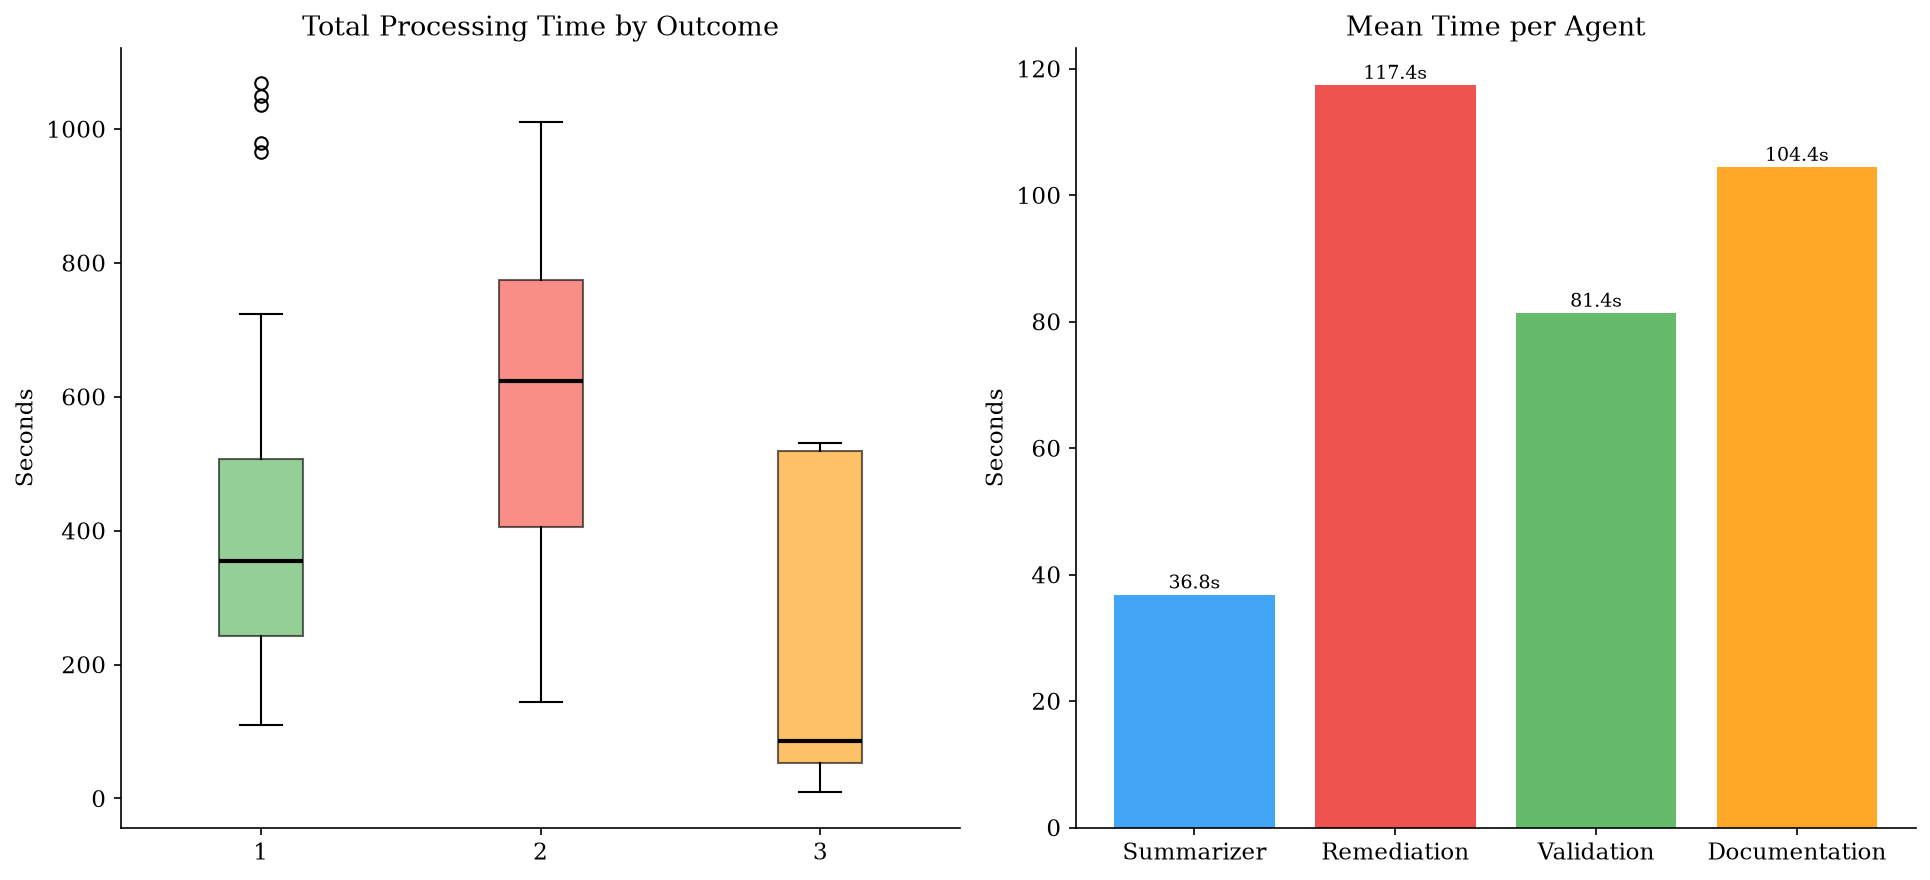

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Box plot by outcome
groups = [
    df[df["outcome"] == o]["total_duration_seconds"].dropna().values
    for o in ["Resolved", "Failed", "False Positive"]
]
bp = axes[0].boxplot(
    groups,
    label=["Resolved", "Failed", "False Positive"],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp["boxes"], ["#4caf50", "#f44336", "#ff9800"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_title("Total Processing Time by Outcome")
axes[0].set_ylabel("Seconds")

# Mean time per agent
means = df[AGENT_COLS].mean().values
bars = axes[1].bar(AGENT_LABELS, means, color=AGENT_COLORS)
for bar, val in zip(bars, means):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}s",
        ha="center",
        fontsize=9,
    )
axes[1].set_title("Mean Time per Agent")
axes[1].set_ylabel("Seconds")

plt.tight_layout()
plt.savefig("results/remediation_time.png", bbox_inches="tight")
plt.show()

In [18]:
JUDGE = Path("results/fix_assessment.jsonl")

judge_records = []
with JUDGE.open(encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        judge_records.append(json.loads(line))

judge_df = pd.DataFrame(judge_records)[
    ["id", "label", "confidence", "acceptable",
     "correctness", "semantic_preservation", "no_regression", "idiomaticity", "notes"]
]

df = df.merge(judge_df, on="id", how="left")

assessed = df["label"].notna()
print(f"Issues with judge assessment : {assessed.sum()} / {len(df)}")
print(f"\nLabel distribution:")
print(df.loc[assessed, "label"].value_counts().to_string())
print(f"\nAcceptable : {df.loc[assessed, 'acceptable'].sum()} / {assessed.sum()}")
print(f"Confidence distribution:")
print(df.loc[assessed, "confidence"].value_counts().to_string())

Issues with judge assessment : 100 / 100

Label distribution:
label
correct              53
incorrect            40
unsafe                6
partially correct     1

Acceptable : 53 / 100
Confidence distribution:
confidence
high      90
medium    10


In [ ]:
# Cross-tabulation: system outcome vs judge label
# label order: correct → partially correct → unsafe → incorrect
LABEL_ORDER   = ["correct", "partially correct", "unsafe", "incorrect"]
OUTCOME_ORDER_ = ["Resolved", "Failed", "False Positive"]

assessed = df["label"].notna()
cross = (
    df[assessed]
    .groupby(["outcome", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=OUTCOME_ORDER_, fill_value=0)
    .reindex(columns=LABEL_ORDER, fill_value=0)
)
cross["Total"] = cross.sum(axis=1)
print("System outcome  ×  Judge label\n")
print(cross.to_string())

print("\n── Discrepancies ──────────────────────────────────────────")
# System resolved but judge says not fully correct
over_reported = df[assessed & (df["outcome"] == "Resolved") & (df["label"] != "correct")]
print(f"\nResolved by system  but judge != correct : {len(over_reported)}")
if len(over_reported):
    print(over_reported[["id", "file_short", "rule", "function", "label", "outcome", "confidence", "notes"]].to_string(index=False))

# System did not resolve but judge says correct
under_reported = df[assessed & (df["outcome"] != "Resolved") & (df["label"] == "correct")]
print(f"\nNot resolved by system  but judge = correct : {len(under_reported)}")
if len(under_reported):
    print(under_reported[["id", "file_short", "rule", "function", "label", "outcome", "confidence", "notes"]].to_string(index=False))

System outcome  ×  Judge label

label           correct  partially correct  unsafe  incorrect  Total
outcome                                                             
Resolved             53                  1       6          1     61
Failed                0                  0       0         34     34
False Positive        0                  0       0          5      5

── Discrepancies ──────────────────────────────────────────

Resolved by system  but judge != correct : 8
                                  id                  file_short             rule             label  outcome confidence                                                                                                                                                                                 notes
d99bd513-43f0-4cba-be44-866423d88e99     materializedGeometry.ts typescript:S7778            unsafe Resolved       high                                                                                               